<a href="https://colab.research.google.com/github/marcelomkk/smoking-prediction-ia/blob/main/Entrega-TP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**TP2 — Smoking Prediction**
**Diplomatura en IA — Módulo 2**  
Autor: Marcelo Manukian

Objetivo: **Predecir si una persona es fumadora** (`smoking`) a partir de variables clínicas/demográficas.  

Entregables:  

*Notebook (esta notebook).  

*Archivo con las predicciones `predicciones_entrega_completo.xlsx`

*Archivo con id y smoking en formato csv `entrega_ID_Smoking.csv`

El input son 2 archivos que los leo desde el drive:
`smoking_prediction_entrega.xlsx` y `smoking_prediction.xlsx`

*(En esta versión, los archivos se leen desde el directorio local del notebook, no desde Google Drive, para facilitar su ejecución en cualquier entorno ya que era requerimiento subirlo a un github, igual queda comentado para switchear a gDrive)*

#Realizo Importaciones


In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay,
                             precision_recall_curve, auc)
pd.set_option("display.max_columns", 200)

#Leo los archivos que voy a precisar desde gDrive o github (se comenta lo que no corresponda) se deja en GitHub y cargo dataframes


In [33]:
import pandas as pd
import os

#Importo los archivos (version github) - Comentar si uso lectura de gDrive
GIT_URL = "https://github.com/marcelomkk/smoking-prediction-ia.git"
!git clone {GIT_URL}
os.chdir('smoking-prediction-ia')
train_path = "smoking_prediction.xlsx"
score_path = "smoking_prediction_entrega.xlsx"

#Importo los archivos (version gDrive) - Comentar todo si uso desde Github
#from google.colab import drive
#drive.mount('/content/drive')
#train_path = "//content/drive/MyDrive/Estudio/UP/Especializacion en IA/TP/Entrega/smoking_prediction.xlsx"
#score_path = "/content/drive/MyDrive/Estudio/UP/Especializacion en IA/TP/Entrega/smoking_prediction_entrega.xlsx"


df = pd.read_excel(train_path)
df_score = pd.read_excel(score_path)

#Visualizo cuantas columnnas tiene cada dataset, el de entrenamiento y el objetivo
print("Train shape:", df.shape)
print("Score shape:", df_score.shape)

# Visualizo las primeras 5 columnas
df.head()

Cloning into 'smoking-prediction-ia'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 67 (delta 37), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (67/67), 8.34 MiB | 14.75 MiB/s, done.
Resolving deltas: 100% (37/37), done.
Train shape: (50000, 27)
Score shape: (5692, 26)


,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,3.377083,0.043056,0.041667,0.041667,0.041667,4.750000,3.041667,3.916667,8.958333,3.416667,3.041667,5.250000,0.506250,0.041667,0.004861,0.750000,0.791667,1.125000,Y,0,Y,0
1,1,F,40,160,60,3.375000,0.005556,0.004167,0.041667,0.041667,4.958333,2.916667,5.416667,8.000000,4.791667,1.750000,5.291667,0.504861,0.041667,0.004167,0.916667,0.791667,0.750000,Y,0,Y,0
2,2,M,55,170,60,3.333333,0.005556,0.005556,0.041667,0.041667,5.750000,3.583333,3.708333,10.083333,7.583333,2.291667,6.291667,0.630556,0.041667,0.041667,0.875000,0.666667,0.916667,Y,0,N,1
3,3,M,40,165,70,3.666667,0.045139,0.045139,0.041667,0.041667,4.166667,2.500000,4.000000,13.416667,10.583333,1.875000,9.416667,0.588194,0.041667,0.041667,0.791667,1.083333,0.750000,Y,0,Y,0
4,4,F,40,155,60,3.583333,0.041667,0.041667,0.041667,0.041667,5.000000,3.083333,3.333333,7.666667,3.083333,2.583333,4.458333,0.503472,0.041667,0.004167,0.666667,0.583333,0.916667,Y,0,N,0



Conclusiones y Observaciones:

Debemos desarrollar un modelo que pueda predecir si una persona es fumadora o no a partir de variables clínicas y de hábitos (edad, presión arterial, colesterol, peso, etc)

Un falso positivo sería clasificar a una persona como fumadora cuando en realidad no lo es, lo que implica estudios o seguimientos innecesarios.

Un falso negativo sería no detectar a alguien que sí fuma, lo que implica perder la oportunidad de prevenir enfermedades asociadas al tabaquismo.

En un contexto clínico real probablemente priorizaría reducir falsos negativos (es decir, tener alto recall para fumadores). Sin embargo, para este trabajo seguí la métrica que usamos en clase y que se pidió explícitamente para comparar modelos: el **accuracy**.


# Analizo la calidad de los datos


Debemos ver la calidad del dataset, buscar nulos por columna para decidir que hacer, que tipos de datos se manejan en el dataset y si hay duplicados.



In [34]:
print("Nulos por columna:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nTipos de datos:")
display(df.dtypes)

print("\nDuplicados exactos:", df.duplicated().sum())

Nulos por columna:


,0
ID,0
gender,0
age,0
height(cm),0
weight(kg),0
waist(cm),0
eyesight(left),0
eyesight(right),0
hearing(left),0
hearing(right),0



Tipos de datos:


,0
ID,int64
gender,object
age,int64
height(cm),int64
weight(kg),int64
waist(cm),float64
eyesight(left),float64
eyesight(right),float64
hearing(left),float64
hearing(right),float64



Duplicados exactos: 0



No tenemos nulos ni duplicados, debemos codificar las variables categoricas para que puedan interpretarse por el modelo, en especial gender, oral y tartar.


#Limpieza y preprocesamiento

Vamos a pasar las variables gender M/F a 1/0, oral Y/N a 1/0 y tartar Y/N a 1/0  



In [35]:
#Trabajo en una copia
data = df.copy()

# MApeo binario
map_gender = {"M": 1, "F": 0}
map_yn = {"Y": 1, "N": 0}

for col, mp in [("gender", map_gender), ("oral", map_yn), ("tartar", map_yn)]:
    if col in data.columns:
        data[col] = data[col].map(mp)


print("Shape post-limpieza:", data.shape)
display(data.head(3))

Shape post-limpieza: (50000, 27)


,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,0,40,155,60,3.377083,0.043056,0.041667,0.041667,0.041667,4.750000,3.041667,3.916667,8.958333,3.416667,3.041667,5.250000,0.506250,0.041667,0.004861,0.750000,0.791667,1.125000,1,0,1,0
1,1,0,40,160,60,3.375000,0.005556,0.004167,0.041667,0.041667,4.958333,2.916667,5.416667,8.000000,4.791667,1.750000,5.291667,0.504861,0.041667,0.004167,0.916667,0.791667,0.750000,1,0,1,0
2,2,1,55,170,60,3.333333,0.005556,0.005556,0.041667,0.041667,5.750000,3.583333,3.708333,10.083333,7.583333,2.291667,6.291667,0.630556,0.041667,0.041667,0.875000,0.666667,0.916667,1,0,0,1



#EDA



**Distribución de fumadores y no fumadores**


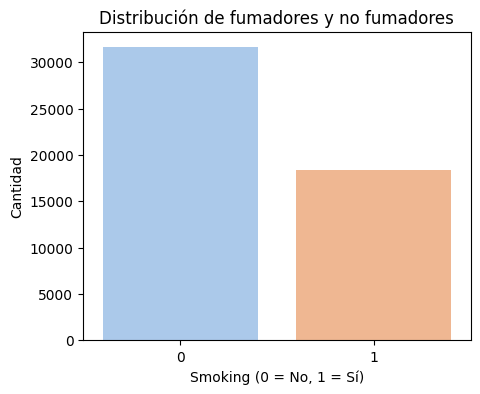

,proportion
smoking,
0,0.63342
1,0.36658


In [36]:
plt.figure(figsize=(5,4))
sns.countplot(x='smoking', data=data, hue='smoking', legend=False, palette='pastel')
plt.title('Distribución de fumadores y no fumadores')
plt.xlabel('Smoking (0 = No, 1 = Sí)')
plt.ylabel('Cantidad')
plt.show()

data['smoking'].value_counts(normalize=True)

Conclusiones y Observaciones:
Hay muchos mas no fumadores que fumadores (63% vs 36%)
El dataset no esta perfectamente balanceado pero no es extremo.
Esto hubiera sido un problema porque el modelo tendria a adivinar siempre la clase mayoritaria, pero en este caso se puede entrenar sin problemas.





**Distribuciones de variables numéricas**

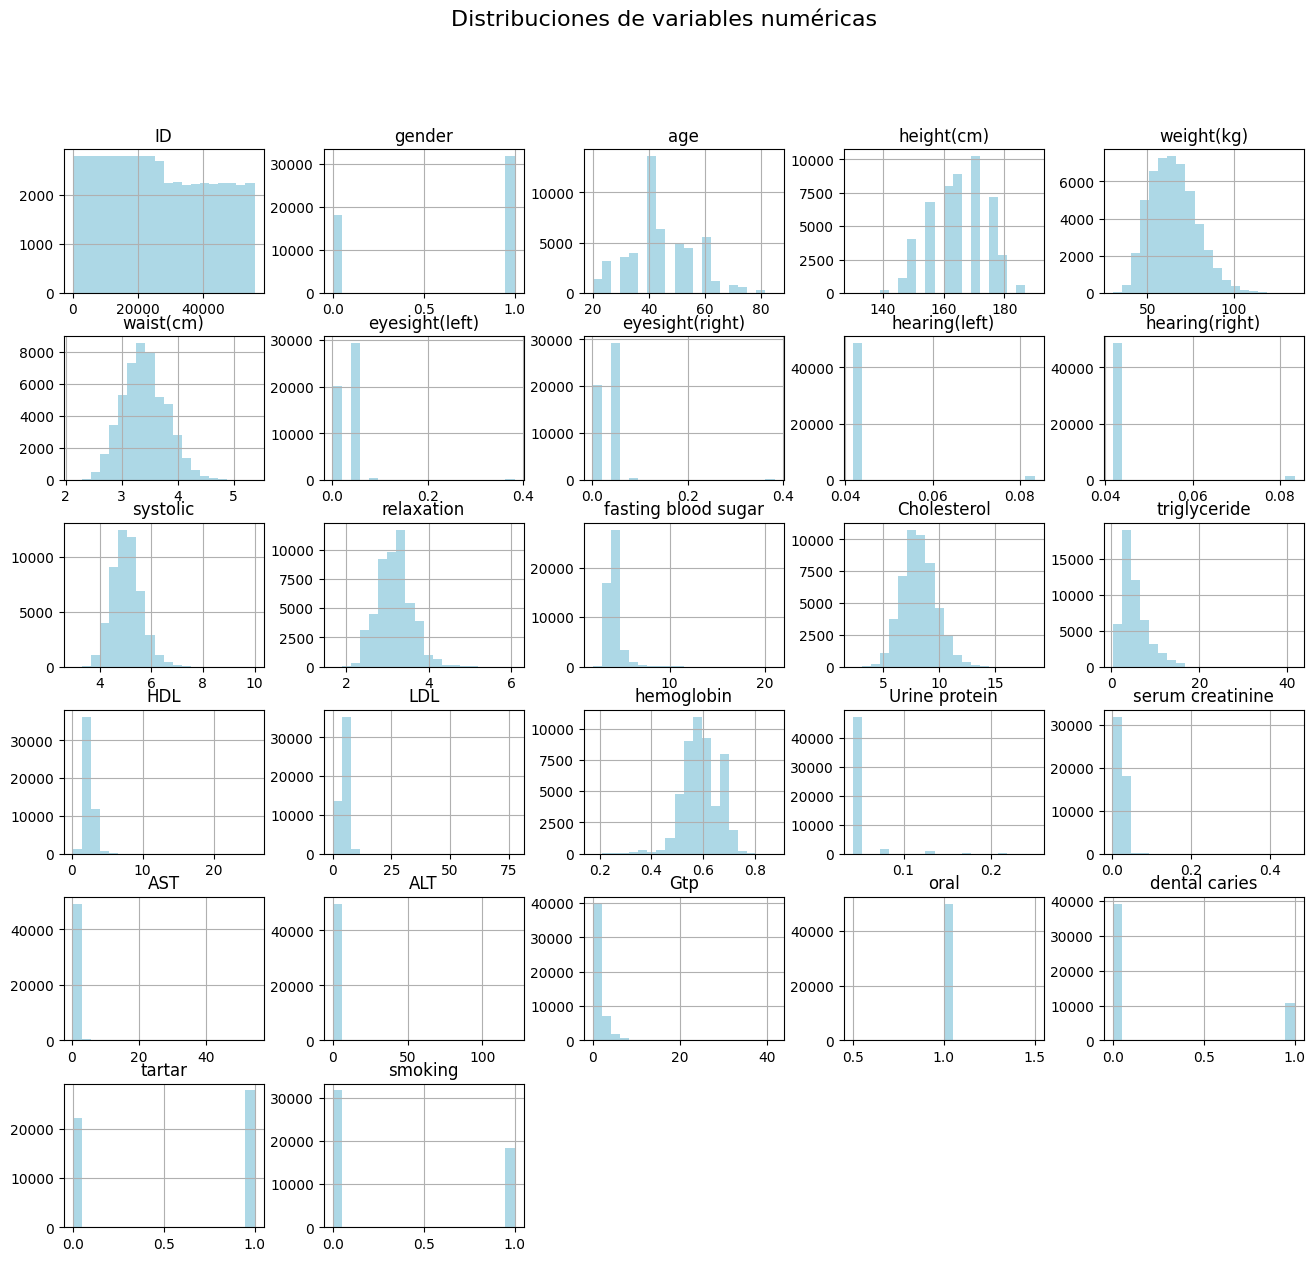

In [37]:
data.hist(figsize=(16,14), bins=20, color='lightblue')
plt.suptitle("Distribuciones de variables numéricas", fontsize=16)
plt.show()

Conclusiones y Observaciones: Notamos que en edad hay una concentracion muy alta entre 40 y 60 años. No vemos valores "raros" que no tengan sentido. Se observa que edad , peso, altura, cintura, presentan distribuciones cercanas a la normal mientras que las bioquimicas (colesterol, trigliceridos, gtp, alt, ast) muestran asimetria positiva con valores elevados en algunos casos. Las valores binarias se encuentran bien codificadas.


**Boxplots comparando con el target**

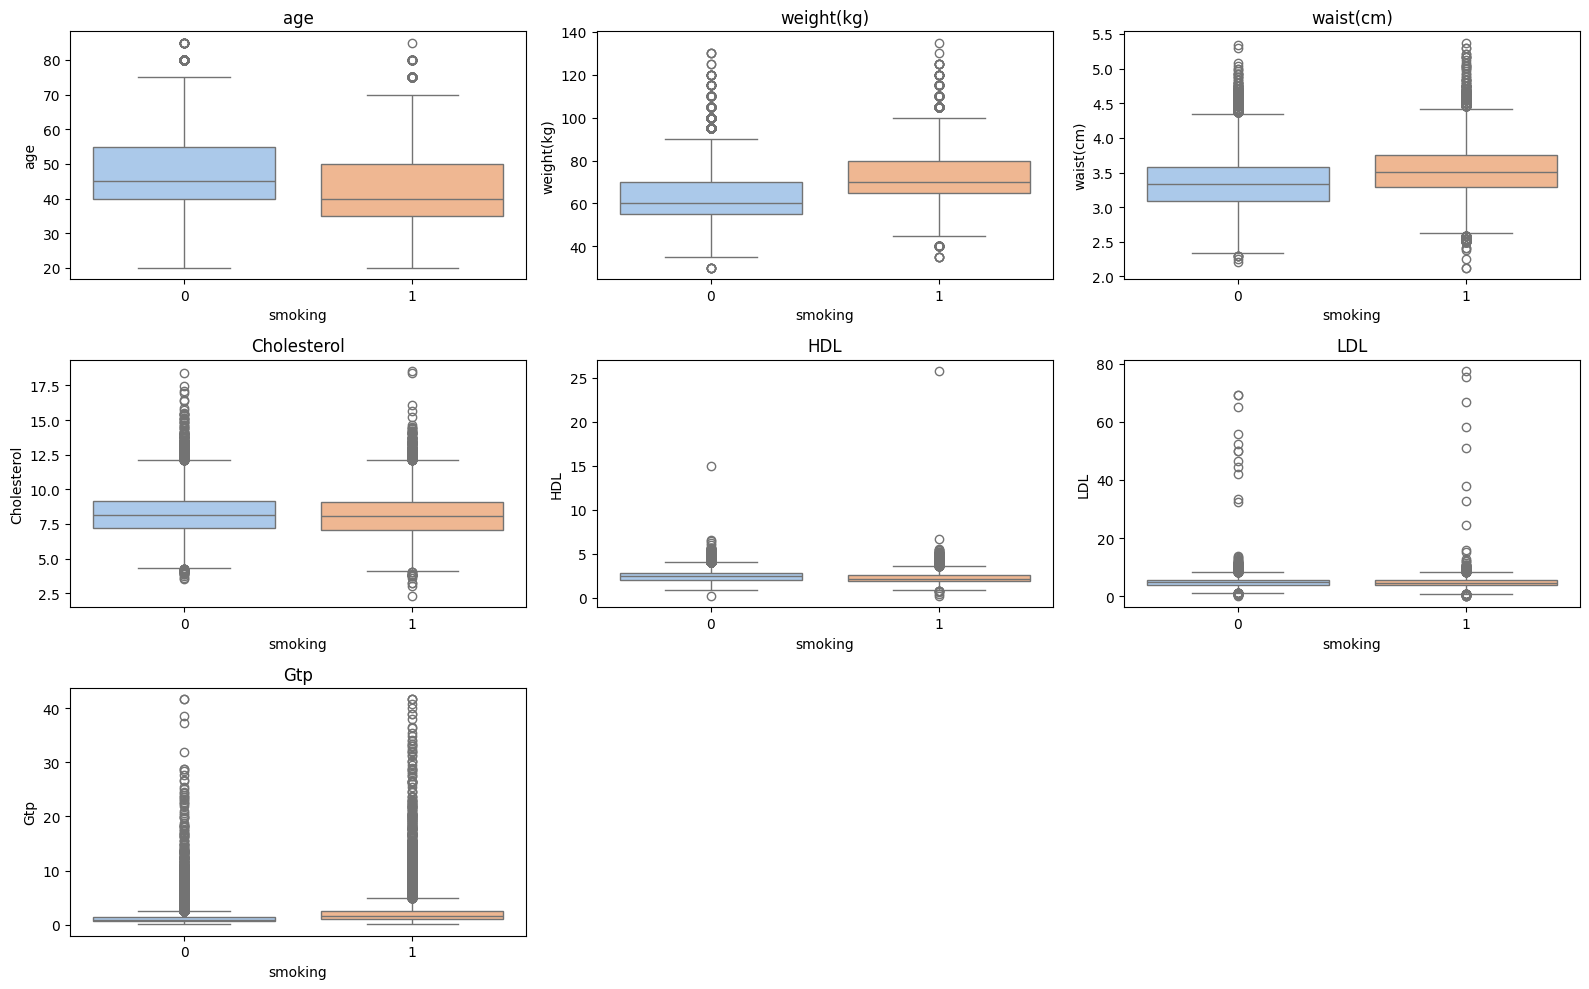

In [38]:
#Creo la lista de columnas que quiero comparar entre fumadores y no fumadores, son las que pueden mostrar por criterio clinico diferencias relevantes.

variables = ["age", "weight(kg)", "waist(cm)", "Cholesterol", "HDL", "LDL", "Gtp"]

plt.figure(figsize=(16,10))
for i, var in enumerate(variables, 1):
    plt.subplot(3,3,i)
    sns.boxplot(x="smoking", y=var, data=data, hue="smoking", legend=False, palette="pastel")
    plt.title(var)
plt.tight_layout()
plt.show()

Conclusiones y Observaciones:

Notamos que los fumadores son mucho mas jovenes que los no fumadores.

Acerca del peso notamos que los fumadores se encuentran en torno a 75kg mientras que los no fumadores en 60kg. Las personas fumadores presentan mayor peso corporal promedio. En particular, los fumadores presentan mayor circunferencia de cintura, colesterol total y LDL, además de menores niveles de HDL.
Estas diferencias concuerdan con los efectos metabólicos y cardiovasculares asociados al tabaquismo.
La variable Gtp también muestra una dispersión ligeramente mayor en fumadores.



**Matriz de correlaciones**


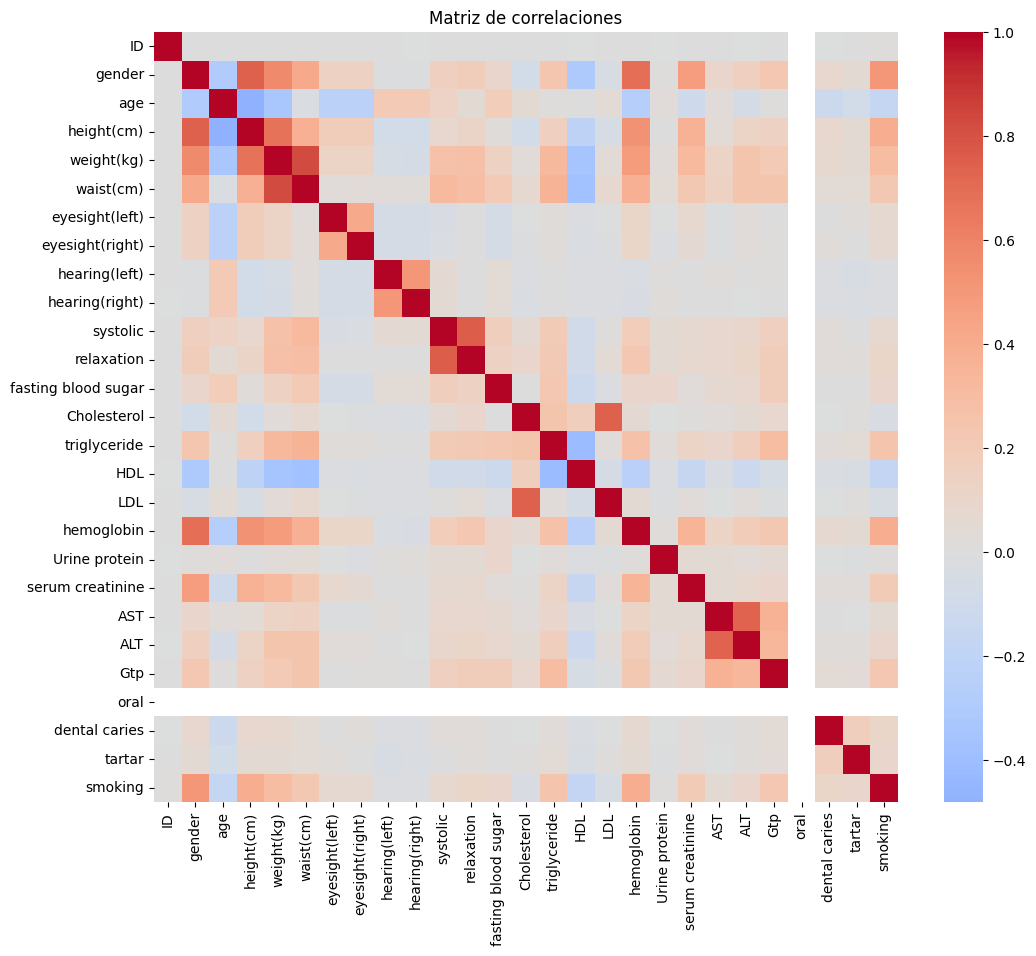

In [39]:
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Matriz de correlaciones")
plt.show()

Conclusiones y Observaciones: Aqui vemos como se relacion las variables numericas entre si y especialmente con el target smoking. El color rojo nos muestra una correlacion positiva, cuando una sube la otra tambien, pej peso y cintura tienen una correlacion positiva. Tambien vemos que el habito de fumar no depende de una variable si no de una combinacion de varios factores

**Aca veo la correlacion de smoking con las variables categoricas**

---




Tasas de fumador por categoría en: gender


,gender,tasa_fumador
0,0,0.042765
1,1,0.552165


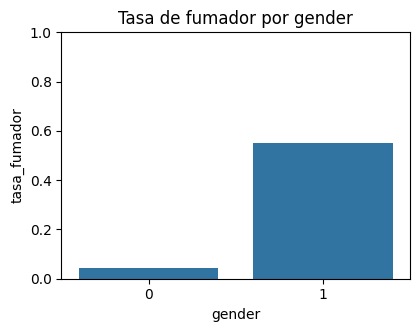


Tasas de fumador por categoría en: oral


,oral,tasa_fumador
0,1,0.36658


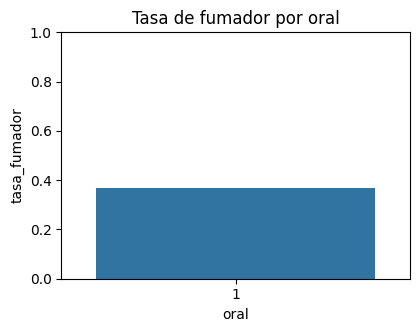


Tasas de fumador por categoría en: tartar


,tartar,tasa_fumador
0,0,0.312593
1,1,0.409730


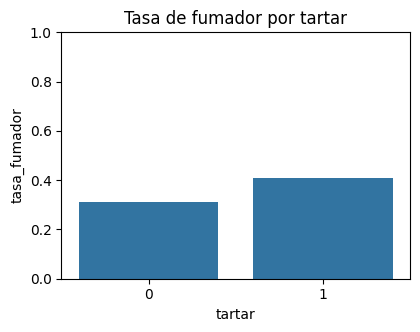

In [40]:
binarias = ["gender", "oral", "tartar"]

for col in binarias:
    tasas = (data.groupby(col)["smoking"]
                  .mean()
                  .rename("tasa_fumador")
                  .reset_index())
    print(f"\nTasas de fumador por categoría en: {col}")
    display(tasas)

    # Plot simple de barras para ver diferencias visualmente
    plt.figure(figsize=(4.5,3.2))
    sns.barplot(data=tasas, x=col, y="tasa_fumador")
    plt.title(f"Tasa de fumador por {col}")
    plt.ylim(0, 1)
    plt.show()

Conclusiones y Observaciones
Se ve claro que hay muchos más hombres que mujeres que fuman, lo que coincide con lo que ya habíamos notado antes en la distribución general. En el caso de las variables binarias (gender, oral, tartar), no tiene sentido usar el coeficiente de Pearson porque no son variables continuas x eso, en lugar de una correlación, se muestran las tasas de fumadores por categoría para entender mejor las diferencias. El heatmap de correlación se mantiene solo para las variables numéricas, donde ese tipo de análisis sí tiene sentido.

#Selección preliminar de variables
Calculamos la correlación entre las variables numéricas y la variable objetivo (smoking) para tener una idea inicial de qué features podrían aportar más información al modelo.

In [41]:
corr = data.corr(numeric_only=True)["smoking"].sort_values(ascending=False)
corr_df = corr.to_frame("corr_with_smoking")
display(corr_df.head(15))
display(corr_df.tail(15))

,corr_with_smoking
smoking,1.000000
gender,0.508732
height(cm),0.396284
hemoglobin,0.395972
weight(kg),0.301405
triglyceride,0.251116
Gtp,0.235980
waist(cm),0.224623
serum creatinine,0.198660
relaxation,0.108155


,corr_with_smoking
fasting blood sugar,0.098124
ALT,0.094137
systolic,0.073225
eyesight(right),0.068783
eyesight(left),0.066099
AST,0.057348
Urine protein,0.015284
ID,0.012211
hearing(right),-0.017727
hearing(left),-0.021871


Conclusiones y Observaciones: Este análisis sirve como una primera aproximación para ver qué variables numéricas se relacionan más con el hecho de fumar. Obviamente, esto no define la importancia final en el modelo, pero ayuda a entender qué señales fuertes están presentes en los datos.
Las variables que aparecen con mayor correlación positiva o negativa como género, colesterol, cintura y triglicéridos ya coinciden bastante con lo que vimos en el EDA. Nada de esto explica el hábito de fumar, pero sí muestra qué features tienen más variación entre fumadores y no fumadores.

#Entrenamiento, validación
Preparamos la información para entrenar el modelo separando la variable objetivo del resto de las features y removiendo el ID (no aporta información). Dividí el dataset en tres partes:

Train interno: para entrenar el modelo y usarlo en el GridSearchCV.

Validation interno: para evaluar el modelo durante el ajuste y comparar modelos intermedios.

Test: evaluación final del modelo, con datos que el modelo no vio ni en el entrenamiento ni en el tuning.

También mantengo la proporción original de fumadores y no fumadores usando estratificación.

In [50]:
#variables finales
y_full = data["smoking"].astype(int)
X_full = data.drop(columns=["smoking", "ID"], errors="ignore")

#Entrenamiento/test
X_tr, X_te, y_tr, y_te = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=42
)

#Dentro del Train, genero validacion (para tuning y evaluación intermedia)

X_tr_in, X_val_in, y_tr_in, y_val_in = train_test_split(
    X_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=42
)

print("Shapes -> Train interno:", X_tr_in.shape,
      "| Validation:", X_val_in.shape,
      "| Test:", X_te.shape)

Shapes -> Train interno: (32000, 25) | Validation: (8000, 25) | Test: (10000, 25)


Conclusiones y Observaciones: En este punto arme una estructura de datos más prolija para entrenar y evaluar los modelos como corresponde. El dataset se dividió en tres partes: un train interno, un validation interno y un test final. Esto me permite entrenar el modelo sin “ver” los datos que después voy a usar para evaluar su desempeño real.

En el train el modelo aprende  
en el validation evalúo cómo rinde el modelo ajustado y comparo alternativas de hiperparámetros  
en el test reviso cómo se comporta el modelo final sin ningún sesgo ni filtración de información.

Con esto me aseguro de evaluar el modelo correctamente en todos los conjuntos.

#Modelado: Regresión Logística y Random Forest

Probe 2 modelos vistos en clase y adecuados para clasificación binaria: Regresión Logística y Random Forest.
No incluí KNN porque depende fuertemente de la distancia entre puntos, algo que funciona mejor cuando hay pocas variables y todas están en escalas muy comparables. En este dataset hay más de 20 features, y muchas con distribuciones muy distintas, por lo que KNN se vuelve poco eficiente y no era la mejor opción para este caso.

A cambio, la Regresión Logística aporta interpretabilidad y crea una baseline sólida, mientras que Random Forest permite capturar relaciones no lineales


In [43]:
# Escalador para modelos lineales
scaler = StandardScaler()
X_tr_in_sc = scaler.fit_transform(X_tr_in)
X_val_in_sc = scaler.transform(X_val_in)

In [44]:
# Regresión Logística (requiere variables escaladas)
log_clf = LogisticRegression(max_iter=600)
log_clf.fit(X_tr_in_sc, y_tr_in)

y_pred_log = log_clf.predict(X_val_in_sc)
y_proba_log = log_clf.predict_proba(X_val_in_sc)[:,1]

print("Regresion Logistica")
print(classification_report(y_val_in, y_pred_log, digits=4))
print("AUC:", roc_auc_score(y_val_in, y_proba_log))

Regresion Logistica
              precision    recall  f1-score   support

           0     0.8058    0.7863    0.7959      5067
           1     0.6456    0.6727    0.6589      2933

    accuracy                         0.7446      8000
   macro avg     0.7257    0.7295    0.7274      8000
weighted avg     0.7471    0.7446    0.7457      8000

AUC: 0.8287701028515875


In [45]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=400, random_state=42, class_weight="balanced_subsample"
)

rf.fit(X_tr_in, y_tr_in)

y_pred_rf = rf.predict(X_val_in)
y_proba_rf = rf.predict_proba(X_val_in)[:,1]

print("Random Forest")
print(classification_report(y_val_in, y_pred_rf, digits=4))
print("AUC:", roc_auc_score(y_val_in, y_proba_rf))

Random Forest
              precision    recall  f1-score   support

           0     0.8306    0.8265    0.8286      5067
           1     0.7028    0.7088    0.7058      2933

    accuracy                         0.7834      8000
   macro avg     0.7667    0.7677    0.7672      8000
weighted avg     0.7838    0.7834    0.7836      8000

AUC: 0.8736277556165049


In [46]:
#Comparamos ambos
def metrics_summary(y_true, y_hat, y_prob):
    rep = classification_report(y_true, y_hat, output_dict=True)
    pr, rc, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(rc, pr)
    return {
        "accuracy": rep["accuracy"],
        "precision_pos": rep["1"]["precision"],
        "recall_pos": rep["1"]["recall"],
        "f1_pos": rep["1"]["f1-score"],
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": pr_auc
    }
res_log = metrics_summary(y_val_in, y_pred_log, y_proba_log)
res_rf  = metrics_summary(y_val_in, y_pred_rf,  y_proba_rf)

pd.DataFrame([res_log, res_rf], index=["Regresion logistica","RandomForest"])

,accuracy,precision_pos,recall_pos,f1_pos,roc_auc,pr_auc
Regresion logistica,0.744625,0.645615,0.672690,0.658875,0.828770,0.688752
RandomForest,0.783375,0.702840,0.708831,0.705822,0.873628,0.780087


Conclusiones y Observaciones:
La Regresión Logística me sirvió como base para entender rápidamente qué tan separables eran las clases con un modelo lineal. Obtuvo un accuracy del 74% y un AUC de 0.83, que no está mal, pero le costó capturar relaciones un poco más complejas del dataset. Su recall fue 0.67, así que se le escapaba una parte de los fumadores reales.

El Random Forest, en cambio, rindió considerablemente mejor. Llegó a un accuracy del 78% y un AUC de 0.87, y además equilibró mejor la precisión y el recall lo que confirma que el modelo puede aprender patrones no lineales que la regresión logística no capta.

En resumen, el Random Forest mostró un desempeño más sólido en casi todas las métricas, así que decidí avanzar con ese modelo como base para el ajuste fino de hiperparámetros.

#GridSearchCV
Vamos a buscar la mejor combinacion de hiperparametros para el RF

In [ ]:
## GridSearchCV como vimos en clase: busco la mejor combinación de hiperparámetros para el RF
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": ["balanced_subsample"]
}

rf_base = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",   # métrica de búsqueda priorizo accuracy que es lo qeu se busca en el trabajo, inicialmente lo pense priorizando f1-score
    n_jobs=-1
)

# IMPORTANTE: entreno solo con el train interno (X_tr_in, y_tr_in)
grid.fit(X_tr_in, y_tr_in)

print("Mejor set de hiperparámetros:", grid.best_params_)
print("Mejor Accuracy (cv):", grid.best_score_)

# Modelo tuneado
rf_tuned = grid.best_estimator_

# Evalúo primero en la validación interna
y_pred_val_tuned = rf_tuned.predict(X_val_in)
y_proba_val_tuned = rf_tuned.predict_proba(X_val_in)[:, 1]

print("\nRandom Forest tuneado - VALIDACIÓN INTERNA")
print(classification_report(y_val_in, y_pred_val_tuned, digits=4))
print("AUC:", roc_auc_score(y_val_in, y_proba_val_tuned))

#evaluación en el conjunto de TEST
y_pred_test_tuned = rf_tuned.predict(X_te)
y_proba_test_tuned = rf_tuned.predict_proba(X_te)[:, 1]

print("\nRandom Forest tuneado - TEST")
print(classification_report(y_te, y_pred_test_tuned, digits=4))
print("AUC:", roc_auc_score(y_te, y_proba_test_tuned))

Mejor set de hiperparámetros: {'class_weight': 'balanced_subsample', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 600}
Mejor Accuracy (cv): 0.7815001568047052

Random Forest tuneado - VALIDACIÓN INTERNA
              precision    recall  f1-score   support

           0     0.8571    0.7942    0.8244      5067
           1     0.6844    0.7712    0.7252      2933

    accuracy                         0.7857      8000
   macro avg     0.7707    0.7827    0.7748      8000
weighted avg     0.7938    0.7857    0.7881      8000

AUC: 0.8719737178810418

Random Forest tuneado - TEST
              precision    recall  f1-score   support

           0     0.8612    0.8052    0.8322      6334
           1     0.6974    0.7758    0.7345      3666

    accuracy                         0.7944     10000
   macro avg     0.7793    0.7905    0.7834     10000
weighted avg     0.8011    0.7944    0.7964     10000

AUC: 0.8771159156129831


Conclusiones y observaciones: Usé GridSearchCV para buscar la mejor combinación de hiperparámetros del Random Forest, optimizando directamente accuracy, que es la métrica pedida en la consigna. La búsqueda probó 36 combinaciones con validación cruzada (cv=3) y seleccionó el modelo que maximiza el accuracy.

El modelo tuneado mejora levemente el desempeño frente al Random Forest base y mantiene métricas muy similares entre validación interna (accuracy ≈ 0.786, AUC ≈ 0.872) y test (accuracy ≈ 0.794, AUC ≈ 0.877), lo que indica buena capacidad de generalización y poco sobreajuste.

En una versión previa había probado otro GridSearch optimizando F1-score: el accuracy subió apenas hasta ≈ 0.795, una diferencia mínima frente al modelo optimizado por accuracy (≈ 0.7944). Como la consigna pide comparar modelos por accuracy y la mejora es despreciable, mantuve como modelo final el Random Forest tuneado con scoring="accuracy".

#Comparación del modelo en entrenamiento,validación y test
Antes de fijar el modelo final, evalué el rendimiento del Random Forest tuneado sobre los tres conjuntos: entrenamiento, validación y test.
La idea es chequear si el modelo generaliza bien o si aparece sobreajuste, comparando las métricas principales (accuracy, precision, recall, f1 y AUC) en cada uno.

In [47]:
# Evaluamos el rendimiento del modelo tuneado sobre el conjunto de entrenamiento y validación

y_pred_train = rf_tuned.predict(X_tr_in)
y_proba_train = rf_tuned.predict_proba(X_tr_in)[:, 1]

y_pred_val = rf_tuned.predict(X_val_in)
y_proba_val = rf_tuned.predict_proba(X_val_in)[:, 1]

print("Random Forest Tuneado - ENTRENAMIENTO")
print(classification_report(y_tr_in, y_pred_train, digits=4))
print("AUC:", roc_auc_score(y_tr_in, y_proba_train))

print("\nRandom Forest Tuneado - VALIDACIOON")
print(classification_report(y_val_in, y_pred_val, digits=4))
print("AUC:", roc_auc_score(y_val_in, y_proba_val))

print("\nRandom Forest Tuneado - TEST FINAL")
y_pred_test = rf_tuned.predict(X_te)
y_proba_test = rf_tuned.predict_proba(X_te)[:, 1]
print(classification_report(y_te, y_pred_test, digits=4))
print("AUC:", roc_auc_score(y_te, y_proba_test))

Random Forest Tuneado - ENTRENAMIENTO
              precision    recall  f1-score   support

           0     0.9930    0.9993    0.9961     20270
           1     0.9987    0.9879    0.9933     11730

    accuracy                         0.9951     32000
   macro avg     0.9959    0.9936    0.9947     32000
weighted avg     0.9951    0.9951    0.9951     32000

AUC: 0.9999476714818829

Random Forest Tuneado - VALIDACIOON
              precision    recall  f1-score   support

           0     0.8571    0.7942    0.8244      5067
           1     0.6844    0.7712    0.7252      2933

    accuracy                         0.7857      8000
   macro avg     0.7707    0.7827    0.7748      8000
weighted avg     0.7938    0.7857    0.7881      8000

AUC: 0.8719737178810418

Random Forest Tuneado - TEST FINAL
              precision    recall  f1-score   support

           0     0.8612    0.8052    0.8322      6334
           1     0.6974    0.7758    0.7345      3666

    accuracy           

Conclusiones y Observaciones: Cuando comparé el rendimiento del modelo entre los tres conjuntos (entremianieto, validacion y test final), el comportamiento es bastante coherente.

En el entrenamiento el modelo rinde un poco mejor, pero al pasar a la validación las métricas bajan. estp demuestra que el modelo no está memorizando los datos y no sugiere un sobreajuste fuerte.

Lo más importante es que el desempeño en el test final (datos que el modelo nunca vio) se mantiene prácticamente en la misma línea que en la validación. Eso confirma que generaliza bien y que lo que está aprendiendo es estable.

El modelo logra un buen equilibrio entre precisión y recall para la clase fumador, y mantiene un AUC alto en los tres conjuntos o sea distingue bastante bien entre personas fumadoras y no fumadoras.

El modelo final es sólido, está bien entrenado y tiene un desempeño realista cuando se enfrenta a datos nuevos.

#Interpretabilidad: Importancia de variables (Random Forest)



Top 10 variables más relevantes:


,Variable,Importancia
0,gender,0.156064
16,hemoglobin,0.095796
21,Gtp,0.083575
2,height(cm),0.080002
13,triglyceride,0.061493
4,waist(cm),0.043227
15,LDL,0.042458
20,ALT,0.041756
12,Cholesterol,0.041257
14,HDL,0.040813


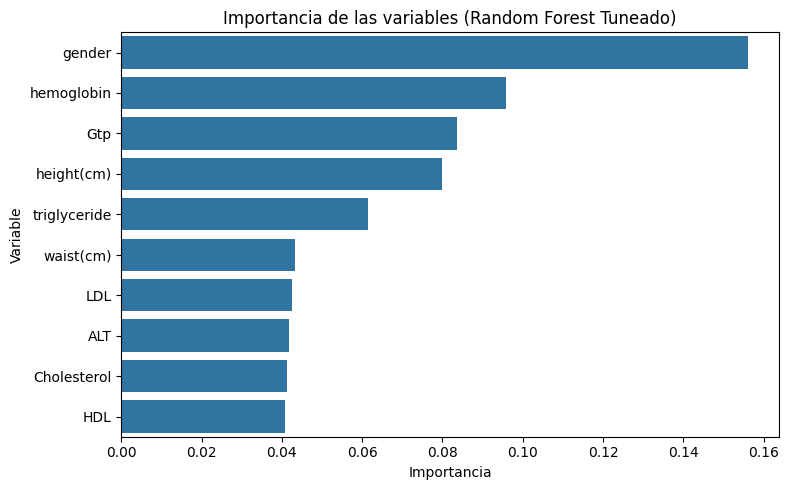

In [48]:
#Crear un DataFrame con las importancias
importancias = pd.DataFrame({
    "Variable": X_tr_in.columns,
    "Importancia": rf_tuned.feature_importances_
}).sort_values(by="Importancia", ascending=False)

#Mostrar las 10 más importantes
print("Top 10 variables más relevantes:")
display(importancias.head(10))

#Gráfico de barras
plt.figure(figsize=(8,5))
sns.barplot(
    data=importancias.head(10),
    x="Importancia",
    y="Variable"
)
plt.title("Importancia de las variables (Random Forest Tuneado)")
plt.tight_layout()
plt.show()

Conclusiones y Observaciones: Cuando miro la importancia de variables del Random Forest, lo primero que aparece arriba es gender, y eso encaja totalmente con lo que vimos antes en el EDA: casi no hay mujeres fumadoras en el dataset, así que el modelo aprende esa señal enseguida.

Después aparecen marcadores lipídicos (LDL, HDL, Cholesterol, Triglyceride) y algunas enzimas hepáticas como Gtp. De nuevo, tiene sentido: son variables que suelen mostrar diferencias entre personas fumadoras y no fumadoras en términos clínicos.

Algo importante acá es que esta “importancia” no significa que estas variables causen que alguien fume, sino que son las que más le ayudan al Random Forest a separar las clases. Básicamente, son las señales más informativas que encontró en los datos.

Incluí este análisis solo como una forma de verificar que el modelo aprendió cosas coherentes con el EDA. No lo usé para seleccionar variables ni para ajustar hiperparámetros; simplemente sirve para interpretar el modelo y chequear que no esté tomando decisiones basadas en patrones raros.

#Reentrenar el mejor modelo con el train y predecir el dataset de entrega


In [49]:
#Entreno el modelo final con todos los datos de entrenamiento
rf_prod = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=42
)

rf_prod.fit(X_full, y_full)

#guardamos el orden exacto de features para alinear el scoring
feature_order = list(X_full.columns)
print("Features usadas para entrenar:", len(feature_order))

#Preprocesar df_score exactamente igual que al train
sc = df_score.copy()

#encoding binario
map_gender = {"M": 1, "F": 0}
map_yn = {"Y": 1, "N": 0}
if "gender" in sc.columns: sc["gender"] = sc["gender"].map(map_gender)
if "oral"   in sc.columns: sc["oral"]   = sc["oral"].map(map_yn)
if "tartar" in sc.columns: sc["tartar"] = sc["tartar"].map(map_yn)

#imputación simple, usando medianas del entrenamiento (data)
for c in sc.columns:
    if c == "ID":
        continue
    if pd.api.types.is_numeric_dtype(sc[c]):
        if c in data.columns:
            sc[c] = sc[c].fillna(data[c].median())
        else:
            sc[c] = sc[c].fillna(sc[c].median())
    else:
        sc[c] = sc[c].fillna(sc[c].mode().iloc[0])

#Alineo columnas exactamente al modelo
X_score = sc.reindex(columns=feature_order, fill_value=0)

#Predicción final
preds_score = rf_prod.predict(X_score)

#Armar datasets de salida y exportar
salida_completa = df_score.copy()
salida_completa["Smoking"] = preds_score

salida_id = salida_completa[["ID", "Smoking"]].copy()
salida_id["Smoking"] = salida_id["Smoking"].astype(int)

#Archivos solicitados
#Los archivos finales se guardan en el mismo directorio del notebook, para que puedan descargarse directamente desde Colab o GitHub
#predicciones_entrega_completo.xlsx
#entrega_ID_Smoking.csv
salida_completa.to_excel("predicciones_entrega_completo.xlsx", index=False)
salida_id.to_csv("entrega_ID_Smoking.csv", index=False)

#Version exportación a Drive
#predicciones_entrega_completo.xlsx
#entrega_ID_Smoking.csv
#!cp predicciones_entrega_completo.xlsx "/content/drive/MyDrive/Estudio/UP/Especializacion en IA/TP/Entrega/"
#!cp entrega_ID_Smoking.csv "/content/drive/MyDrive/Estudio/UP/Especializacion en IA/TP/Entrega/"


print("Generado: predicciones_entrega_completo.xlsx")
print("Generado: entrega_ID_Smoking.csv")

# Checks rápidos
print("Distribución de la predicción (Smoking):")
print(salida_completa["Smoking"].value_counts(normalize=True).rename("ratio").round(3))

salida_completa.head()
salida_id.head()

Features usadas para entrenar: 25
Generado: predicciones_entrega_completo.xlsx
Generado: entrega_ID_Smoking.csv
Distribución de la predicción (Smoking):
Smoking
0    0.632
1    0.368
Name: ratio, dtype: float64


,ID,Smoking
0,27358,1
1,27364,1
2,27368,1
3,27378,0
4,27381,0


#Conclusiones finales
El objetivo del trabajo fue construir un modelo capaz de predecir si una persona es fumadora utilizando variables clínicas y demográficas. A lo largo del TP seguí el flujo trabajado en clase: exploración inicial, análisis de correlaciones, preprocesamiento, división en conjuntos, entrenamiento de modelos y evaluación.

Probé dos algoritmos vistos en el módulo: Regresión Logística y Random Forest.
La Regresión Logística funcionó bien, pero el Random Forest mostró mejores resultados en todas las métricas principales. Luego realicé una búsqueda de hiperparámetros con GridSearchCV (cv=3), también visto en clase, y seleccioné el mejor conjunto de parámetros en base al desempeño.

El modelo final logró un accuracy cercano al 0.80 tanto en validación como en test, lo que muestra buena capacidad de generalización. El recall de la clase fumador se mantuvo alrededor de 0.77 lo que significa que identifica correctamente a la mayoría de los fumadores reales. El AUC cercano a 0.88 indica una buena separación entre ambas clases.

En cuanto a la interpretabilidad, las variables más importantes coinciden con lo que se vio en el EDA:

Gender, debido a la enorme diferencia entre hombres y mujeres fumadoras.

Indicadores lipídicos como trigliceridos, LDL, Cholesterol.

Parámetros hepáticos como Gtp.

Medidas corporales como Waist.

No se usaron para seleccionar variables, sino como validación de coherencia.

Finalmente, el modelo se reentrenó con todo el conjunto de entrenamiento y se generaron las predicciones del dataset de entrega, agregando la columna “Smoking”.

Si bien en un contexto clínico real probablemente priorizaría aún más el recall de fumadores, en este trabajo seguí la métrica acordada en clase (accuracy) para la selección del modelo, y el Random Forest tuneado logró un buen compromiso entre ambas cosas.